# Paso 3: EDA Univariado - Análisis de Transacciones Bancarias

Este notebook contiene el análisis exploratorio univariado (una variable a la vez) del dataset de transacciones bancarias.

**Objetivo**: Entender la distribución individual de cada variable sin realizar limpieza, imputación o modelado.

## Setup: Importar Librerías

Importamos las librerías necesarias para el análisis: pandas, numpy, matplotlib y seaborn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Configurar matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Crear directorio para guardar figuras si no existe
os.makedirs('outputs/figures', exist_ok=True)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## Cargar Dataset

Verificamos si ya existe `df` en el entorno. Si no existe, lo cargamos desde `data/transacciones_banco.csv`.

In [29]:
df=pd.read_csv('../data/transacciones_banco.csv')

In [30]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

## Definir Listas de Variables

Clasificamos las variables en numéricas y categóricas para un análisis sistemático.

In [ ]:
# Variables numéricas
numeric_vars = ['TransactionAmount', 'AccountBalance', 'CustomerAge', 
                'TransactionDuration', 'LoginAttempts']

# Variables categóricas
categorical_vars = ['TransactionType', 'Channel', 'CustomerOccupation', 
                    'Location', 'MerchantID']

# Variables de alta cardinalidad (IDs únicos - solo reportar estadísticas básicas)
high_cardinality_vars = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address']

# Variables temporales (fechas)
temporal_vars = ['TransactionDate', 'PreviousTransactionDate']

print("Variables Numéricas:", numeric_vars)
print("\nVariables Categóricas:", categorical_vars)
print("\nVariables de Alta Cardinalidad:", high_cardinality_vars)
print("\nVariables Temporales:", temporal_vars)
print(f"\nTotal de variables clasificadas: {len(numeric_vars) + len(categorical_vars) + len(high_cardinality_vars) + len(temporal_vars)} de {len(df.columns)}")

Variables Numéricas: ['TransactionAmount', 'AccountBalance', 'CustomerAge', 'TransactionDuration', 'LoginAttempts']

Variables Categóricas: ['TransactionType', 'Channel', 'CustomerOccupation', 'Location', 'MerchantID']

Variables de Alta Cardinalidad: ['TransactionID', 'AccountID', 'DeviceID', 'IP Address']

Variables Temporales: ['TransactionDate', 'PreviousTransactionDate']

Total de variables clasificadas: 16 de 16


# Análisis de Variables Numéricas

Analizamos la distribución de cada variable numérica con estadísticas descriptivas y visualizaciones.

## Estadísticas Descriptivas: Todas las Variables Numéricas

Generamos estadísticas con percentiles personalizados para detectar valores extremos.

In [ ]:
# Estadísticas descriptivas con percentiles personalizados
desc_stats = df[numeric_vars].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
display(desc_stats)

,TransactionAmount,AccountBalance,CustomerAge,TransactionDuration,LoginAttempts
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,5114.302966,44.673965,119.643312,1.124602
std,291.946243,3900.942499,17.792198,69.963757,0.602662
min,0.260000,101.250000,18.000000,10.000000,1.000000
1%,4.398800,165.918300,18.000000,12.110000,1.000000
5%,16.220500,390.229500,20.000000,24.000000,1.000000
50%,211.140000,4735.510000,45.000000,112.500000,1.000000
95%,878.179000,12900.271000,74.000000,265.000000,1.000000
99%,1360.597400,14487.890400,79.000000,291.890000,5.000000
max,1919.110000,14977.990000,80.000000,300.000000,5.000000


## TransactionAmount: Distribución

Analizamos el monto de las transacciones con histograma, KDE y boxplot. Incluimos visualización con escala logarítmica para manejar valores extremos.

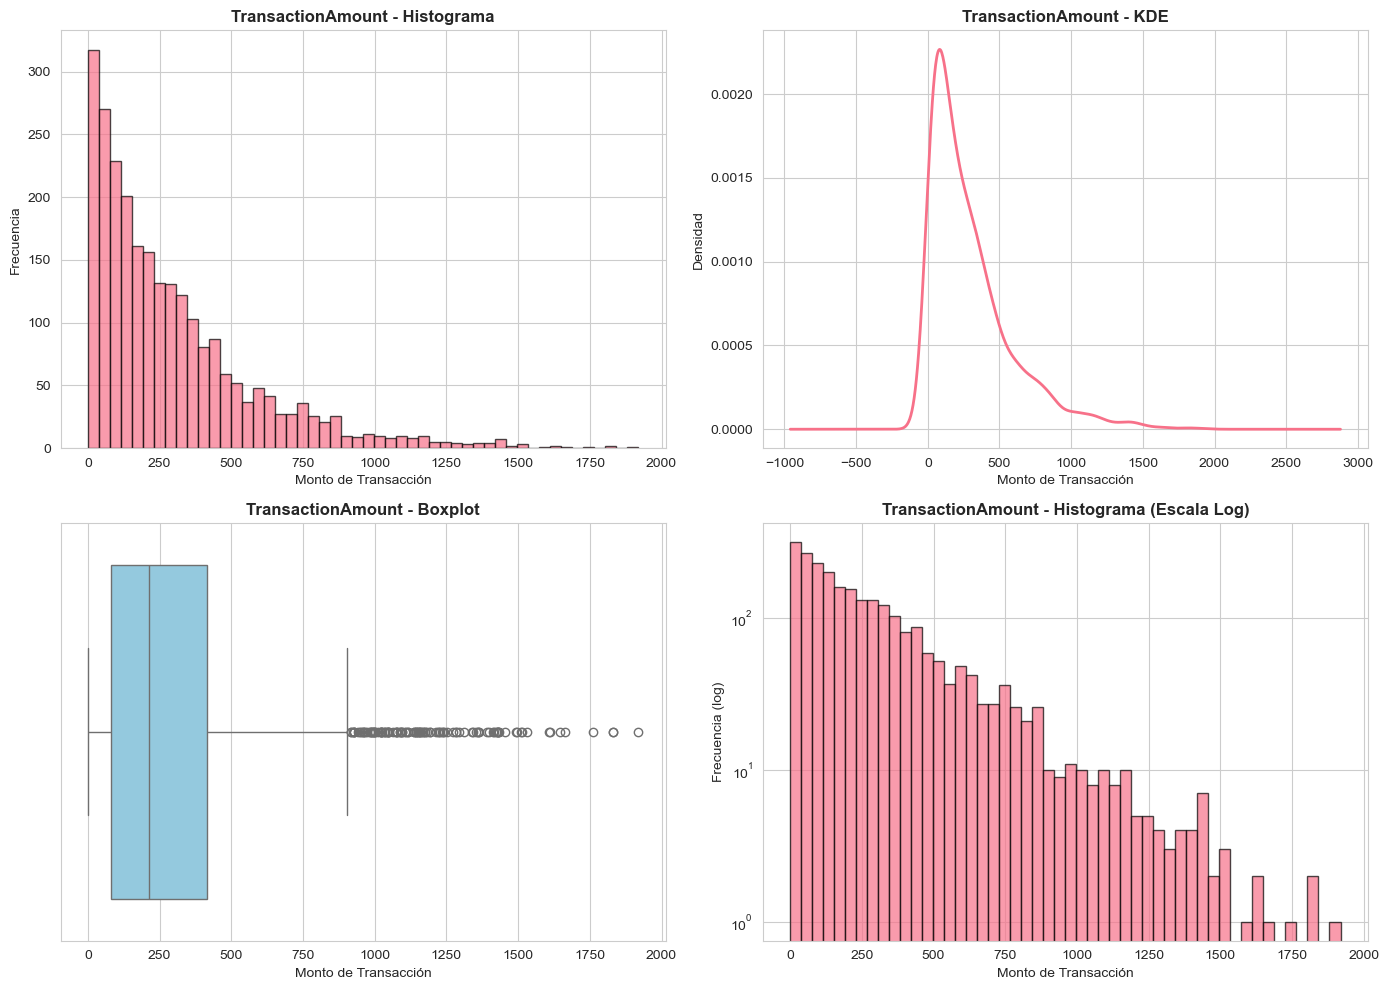


TransactionAmount - Estadísticas:
Media: $297.59
Mediana: $211.14
Desv. Estándar: $291.95
Mín: $0.26
Máx: $1,919.11


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma + KDE
axes[0, 0].hist(df['TransactionAmount'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('TransactionAmount - Histograma', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Monto de Transacción')
axes[0, 0].set_ylabel('Frecuencia')

# KDE
df['TransactionAmount'].dropna().plot(kind='density', ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title('TransactionAmount - KDE', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Monto de Transacción')
axes[0, 1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=df['TransactionAmount'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('TransactionAmount - Boxplot', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Monto de Transacción')

# Histograma con escala logarítmica
axes[1, 1].hist(df['TransactionAmount'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('TransactionAmount - Histograma (Escala Log)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Monto de Transacción')
axes[1, 1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.savefig('outputs/figures/transaction_amount_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas específicas
print(f"\nTransactionAmount - Estadísticas:")
print(f"Media: ${df['TransactionAmount'].mean():,.2f}")
print(f"Mediana: ${df['TransactionAmount'].median():,.2f}")
print(f"Desv. Estándar: ${df['TransactionAmount'].std():,.2f}")
print(f"Mín: ${df['TransactionAmount'].min():,.2f}")
print(f"Máx: ${df['TransactionAmount'].max():,.2f}")

## AccountBalance: Distribución

Analizamos el saldo de cuenta con histograma, KDE y boxplot. Incluimos visualización con escala logarítmica para valores extremos.

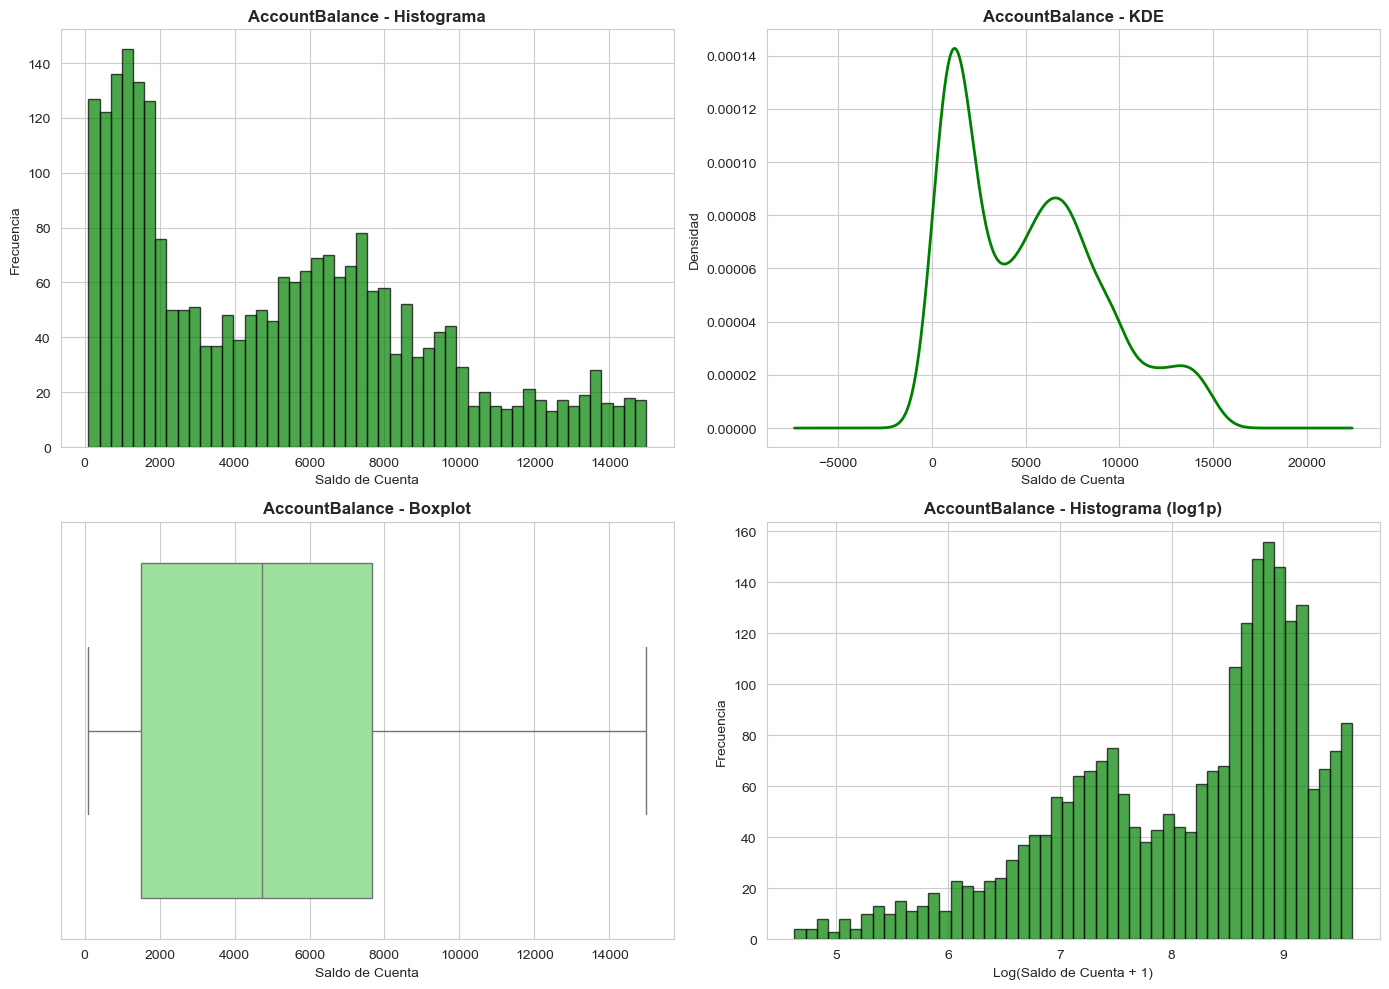


AccountBalance - Estadísticas:
Media: $5,114.30
Mediana: $4,735.51
Desv. Estándar: $3,900.94
Mín: $101.25
Máx: $14,977.99


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma + KDE
axes[0, 0].hist(df['AccountBalance'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 0].set_title('AccountBalance - Histograma', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Saldo de Cuenta')
axes[0, 0].set_ylabel('Frecuencia')

# KDE
df['AccountBalance'].dropna().plot(kind='density', ax=axes[0, 1], linewidth=2, color='green')
axes[0, 1].set_title('AccountBalance - KDE', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Saldo de Cuenta')
axes[0, 1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=df['AccountBalance'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('AccountBalance - Boxplot', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Saldo de Cuenta')

# Histograma con transformación log1p
account_balance_log = np.log1p(df['AccountBalance'].dropna())
axes[1, 1].hist(account_balance_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('AccountBalance - Histograma (log1p)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Log(Saldo de Cuenta + 1)')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('outputs/figures/account_balance_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas específicas
print(f"\nAccountBalance - Estadísticas:")
print(f"Media: ${df['AccountBalance'].mean():,.2f}")
print(f"Mediana: ${df['AccountBalance'].median():,.2f}")
print(f"Desv. Estándar: ${df['AccountBalance'].std():,.2f}")
print(f"Mín: ${df['AccountBalance'].min():,.2f}")
print(f"Máx: ${df['AccountBalance'].max():,.2f}")

## CustomerAge: Distribución

Analizamos la edad de los clientes con histograma, KDE y boxplot.

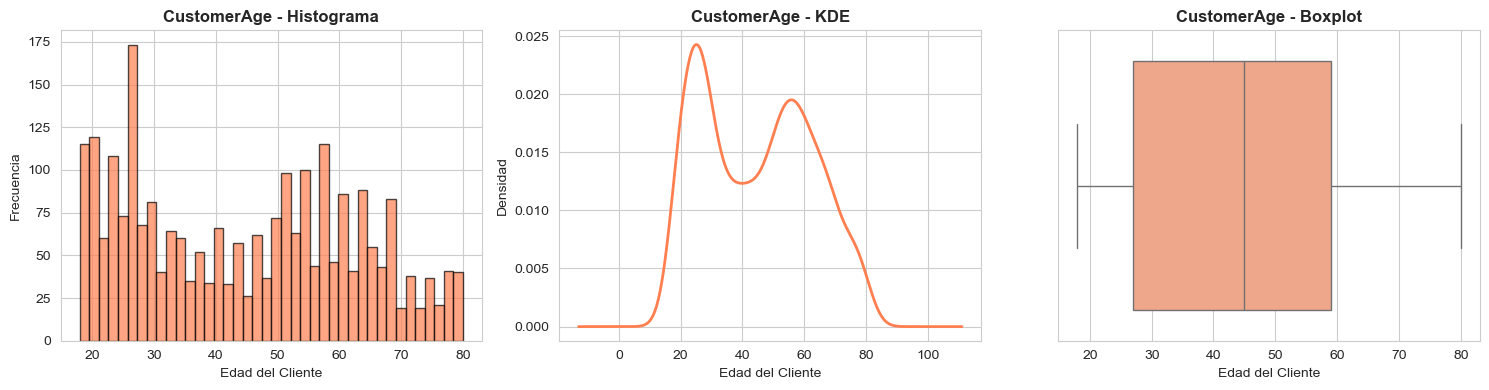


CustomerAge - Estadísticas:
Media: 44.7 años
Mediana: 45.0 años
Desv. Estándar: 17.8 años
Mín: 18 años
Máx: 80 años


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df['CustomerAge'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('CustomerAge - Histograma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad del Cliente')
axes[0].set_ylabel('Frecuencia')

# KDE
df['CustomerAge'].dropna().plot(kind='density', ax=axes[1], linewidth=2, color='coral')
axes[1].set_title('CustomerAge - KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad del Cliente')
axes[1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=df['CustomerAge'], ax=axes[2], color='lightsalmon')
axes[2].set_title('CustomerAge - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Edad del Cliente')

plt.tight_layout()
plt.show()

# Estadísticas específicas
print(f"\nCustomerAge - Estadísticas:")
print(f"Media: {df['CustomerAge'].mean():.1f} años")
print(f"Mediana: {df['CustomerAge'].median():.1f} años")
print(f"Desv. Estándar: {df['CustomerAge'].std():.1f} años")
print(f"Mín: {df['CustomerAge'].min():.0f} años")
print(f"Máx: {df['CustomerAge'].max():.0f} años")

## TransactionDuration: Distribución

Analizamos la duración de las transacciones con histograma, KDE y boxplot.

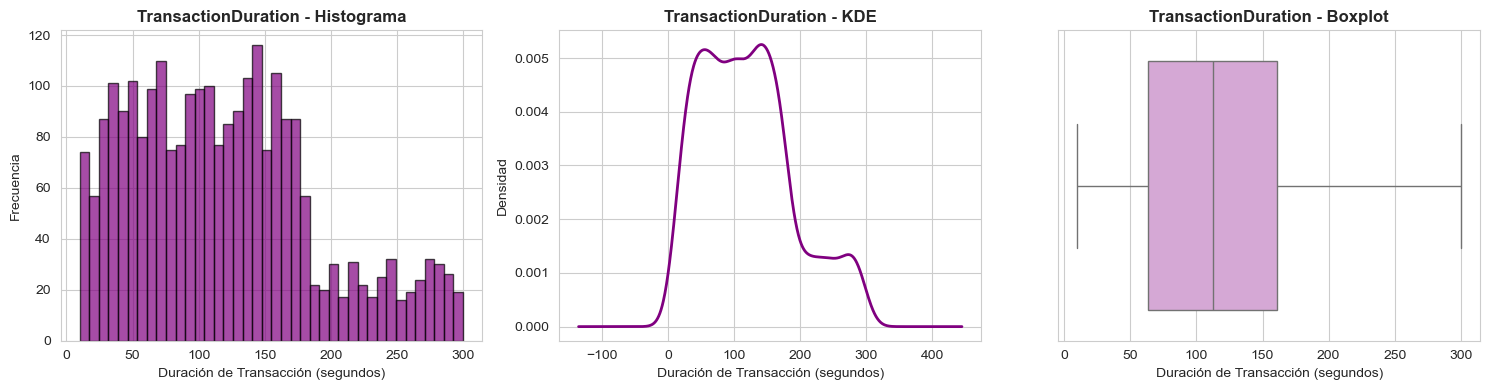


TransactionDuration - Estadísticas:
Media: 119.6 segundos
Mediana: 112.5 segundos
Desv. Estándar: 70.0 segundos
Mín: 10 segundos
Máx: 300 segundos


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df['TransactionDuration'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_title('TransactionDuration - Histograma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duración de Transacción (segundos)')
axes[0].set_ylabel('Frecuencia')

# KDE
df['TransactionDuration'].dropna().plot(kind='density', ax=axes[1], linewidth=2, color='purple')
axes[1].set_title('TransactionDuration - KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Duración de Transacción (segundos)')
axes[1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=df['TransactionDuration'], ax=axes[2], color='plum')
axes[2].set_title('TransactionDuration - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Duración de Transacción (segundos)')

plt.tight_layout()
plt.show()

# Estadísticas específicas
print(f"\nTransactionDuration - Estadísticas:")
print(f"Media: {df['TransactionDuration'].mean():.1f} segundos")
print(f"Mediana: {df['TransactionDuration'].median():.1f} segundos")
print(f"Desv. Estándar: {df['TransactionDuration'].std():.1f} segundos")
print(f"Mín: {df['TransactionDuration'].min():.0f} segundos")
print(f"Máx: {df['TransactionDuration'].max():.0f} segundos")

## LoginAttempts: Distribución

Analizamos los intentos de login con histograma, KDE y boxplot. Esta variable es clave para detectar comportamientos sospechosos.

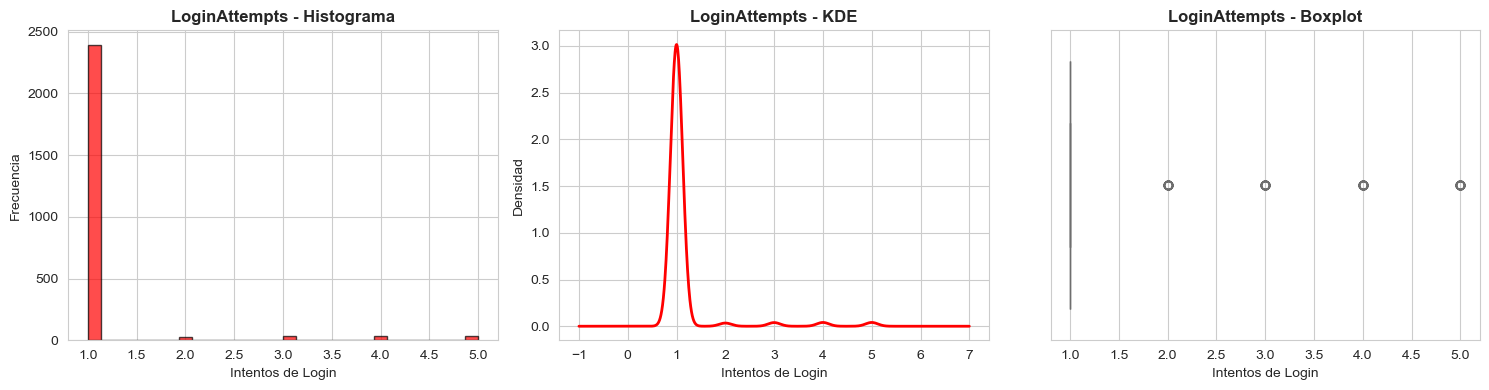


LoginAttempts - Estadísticas:
Media: 1.12 intentos
Mediana: 1.0 intentos
Desv. Estándar: 0.60 intentos
Mín: 1 intentos
Máx: 5 intentos

Valores únicos: 5


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df['LoginAttempts'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('LoginAttempts - Histograma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Intentos de Login')
axes[0].set_ylabel('Frecuencia')

# KDE
df['LoginAttempts'].dropna().plot(kind='density', ax=axes[1], linewidth=2, color='red')
axes[1].set_title('LoginAttempts - KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Intentos de Login')
axes[1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=df['LoginAttempts'], ax=axes[2], color='lightcoral')
axes[2].set_title('LoginAttempts - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Intentos de Login')

plt.tight_layout()
plt.savefig('outputs/figures/login_attempts_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Estadísticas específicas
print(f"\nLoginAttempts - Estadísticas:")
print(f"Media: {df['LoginAttempts'].mean():.2f} intentos")
print(f"Mediana: {df['LoginAttempts'].median():.1f} intentos")
print(f"Desv. Estándar: {df['LoginAttempts'].std():.2f} intentos")
print(f"Mín: {df['LoginAttempts'].min():.0f} intentos")
print(f"Máx: {df['LoginAttempts'].max():.0f} intentos")
print(f"\nValores únicos: {df['LoginAttempts'].nunique()}")

# Análisis de Variables Categóricas

Analizamos la distribución de cada variable categórica con frecuencias y visualizaciones.

## TransactionType: Distribución

Analizamos la frecuencia de cada tipo de transacción.

TransactionType - Frecuencias Absolutas:
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

TransactionType - Frecuencias Relativas (%):
TransactionType
Debit     77.388535
Credit    22.611465
Name: proportion, dtype: float64


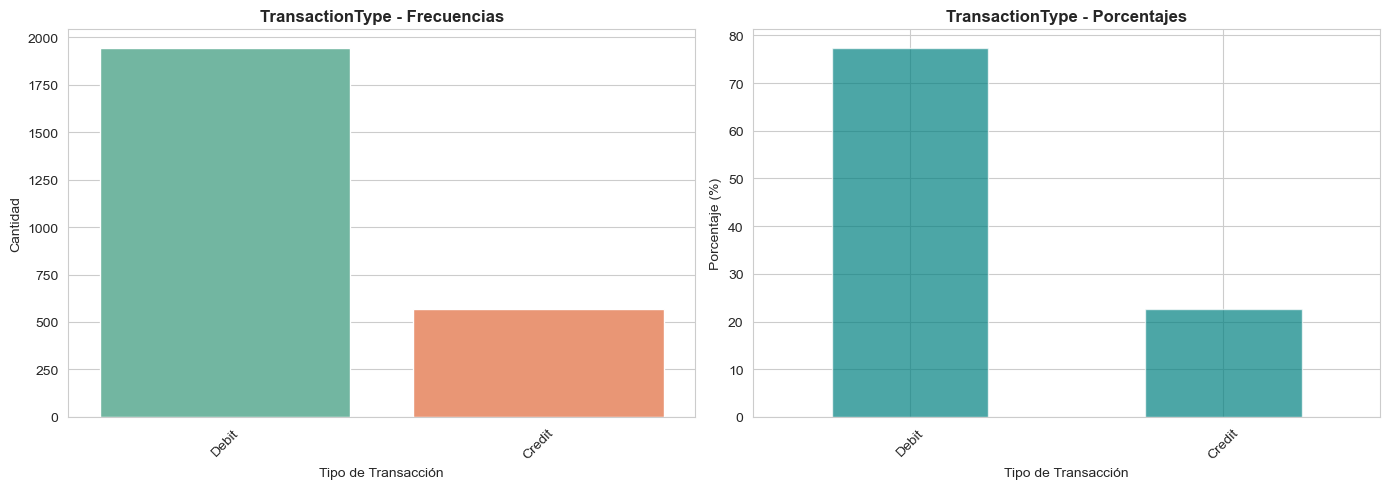

In [ ]:
# Frecuencias absolutas y relativas
print("TransactionType - Frecuencias Absolutas:")
print(df['TransactionType'].value_counts())
print("\nTransactionType - Frecuencias Relativas (%):")
print(df['TransactionType'].value_counts(normalize=True) * 100)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(data=df, x='TransactionType', ax=axes[0], palette='Set2', order=df['TransactionType'].value_counts().index)
axes[0].set_title('TransactionType - Frecuencias', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de Transacción')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Barplot con porcentajes
trans_pct = df['TransactionType'].value_counts(normalize=True) * 100
trans_pct.plot(kind='bar', ax=axes[1], color='teal', alpha=0.7)
axes[1].set_title('TransactionType - Porcentajes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de Transacción')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Channel: Distribución

Analizamos la distribución de los canales de transacción.

Channel - Frecuencias Absolutas:
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

Channel - Frecuencias Relativas (%):
Channel
Branch    34.554140
ATM       33.160828
Online    32.285032
Name: proportion, dtype: float64


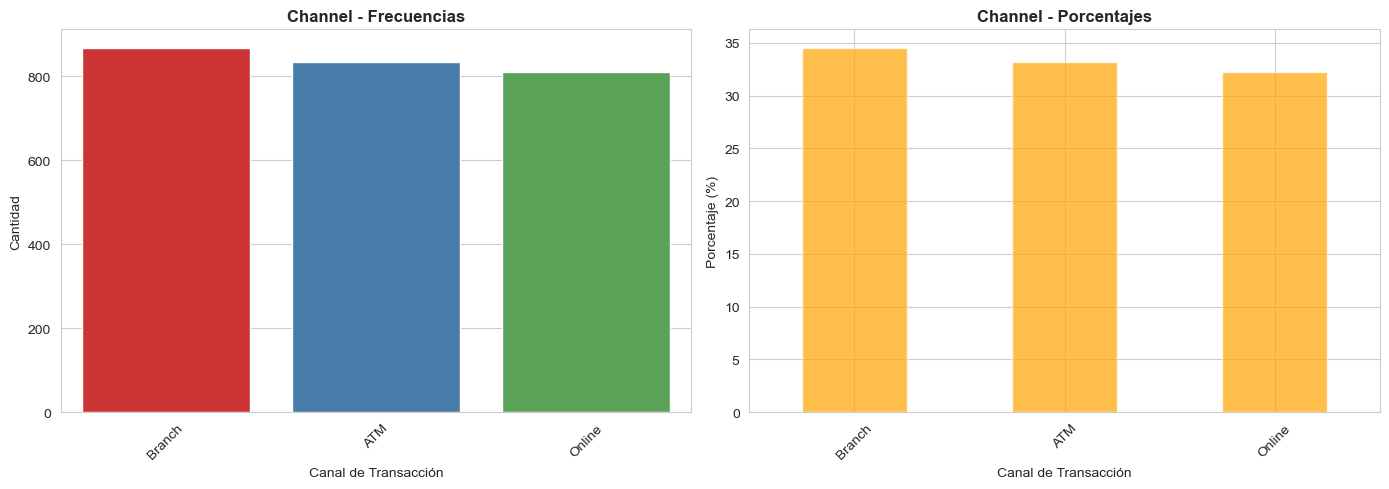

In [ ]:
# Frecuencias absolutas y relativas
print("Channel - Frecuencias Absolutas:")
print(df['Channel'].value_counts())
print("\nChannel - Frecuencias Relativas (%):")
print(df['Channel'].value_counts(normalize=True) * 100)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(data=df, x='Channel', ax=axes[0], palette='Set1', order=df['Channel'].value_counts().index)
axes[0].set_title('Channel - Frecuencias', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Canal de Transacción')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Barplot con porcentajes
channel_pct = df['Channel'].value_counts(normalize=True) * 100
channel_pct.plot(kind='bar', ax=axes[1], color='orange', alpha=0.7)
axes[1].set_title('Channel - Porcentajes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Canal de Transacción')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/figures/channel_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## CustomerOccupation: Distribución

Analizamos la distribución de ocupaciones de los clientes.

CustomerOccupation - Frecuencias Absolutas:
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64

CustomerOccupation - Frecuencias Relativas (%):
CustomerOccupation
Student     26.154459
Doctor      25.119427
Engineer    24.880573
Retired     23.845541
Name: proportion, dtype: float64


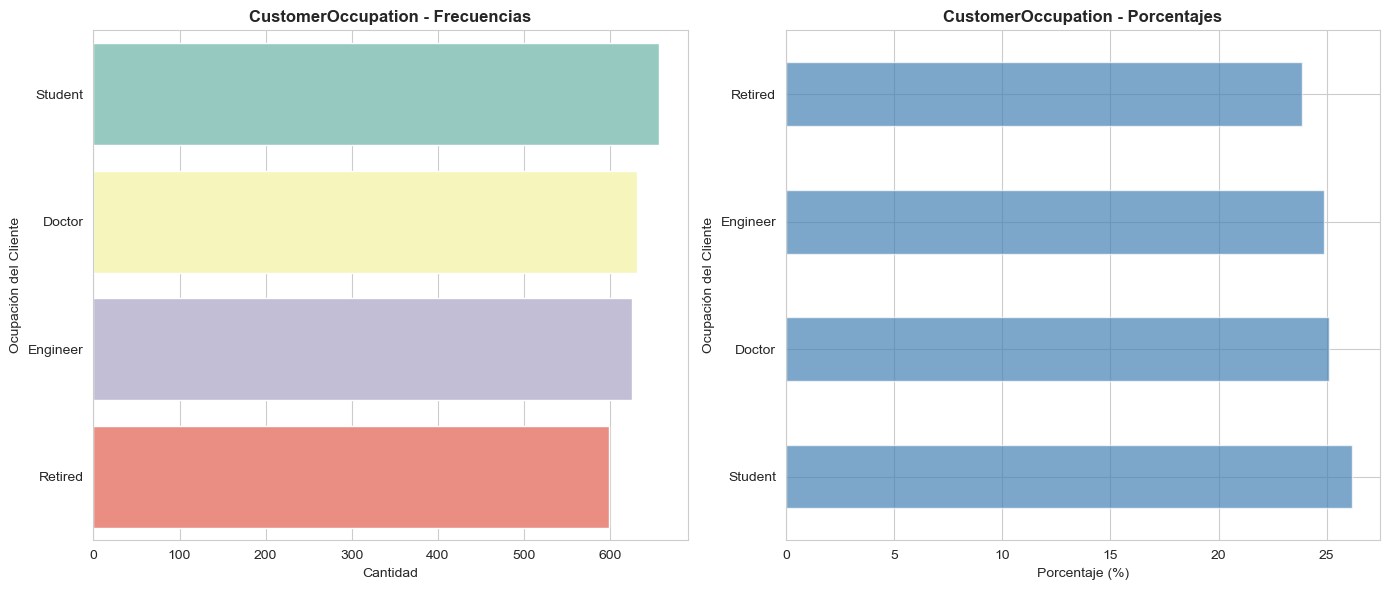

In [ ]:
# Frecuencias absolutas y relativas
print("CustomerOccupation - Frecuencias Absolutas:")
print(df['CustomerOccupation'].value_counts())
print("\nCustomerOccupation - Frecuencias Relativas (%):")
print(df['CustomerOccupation'].value_counts(normalize=True) * 100)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(data=df, y='CustomerOccupation', ax=axes[0], palette='Set3', 
              order=df['CustomerOccupation'].value_counts().index)
axes[0].set_title('CustomerOccupation - Frecuencias', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ocupación del Cliente')
axes[0].set_xlabel('Cantidad')

# Barplot con porcentajes
occupation_pct = df['CustomerOccupation'].value_counts(normalize=True) * 100
occupation_pct.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('CustomerOccupation - Porcentajes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_ylabel('Ocupación del Cliente')

plt.tight_layout()
plt.show()

## Location: Top 10 (Alta Cardinalidad)

Debido a la alta cardinalidad de Location, mostramos solo las 10 ubicaciones más frecuentes.

Total de ubicaciones únicas: 43
Total de transacciones: 2512

Location - Top 10 Frecuencias:
Location
Fort Worth       70
Los Angeles      69
Oklahoma City    68
Charlotte        68
Tucson           67
Philadelphia     67
Omaha            65
Miami            64
Detroit          63
Houston          63
Name: count, dtype: int64

El Top 10 representa el 26.43% del total de transacciones



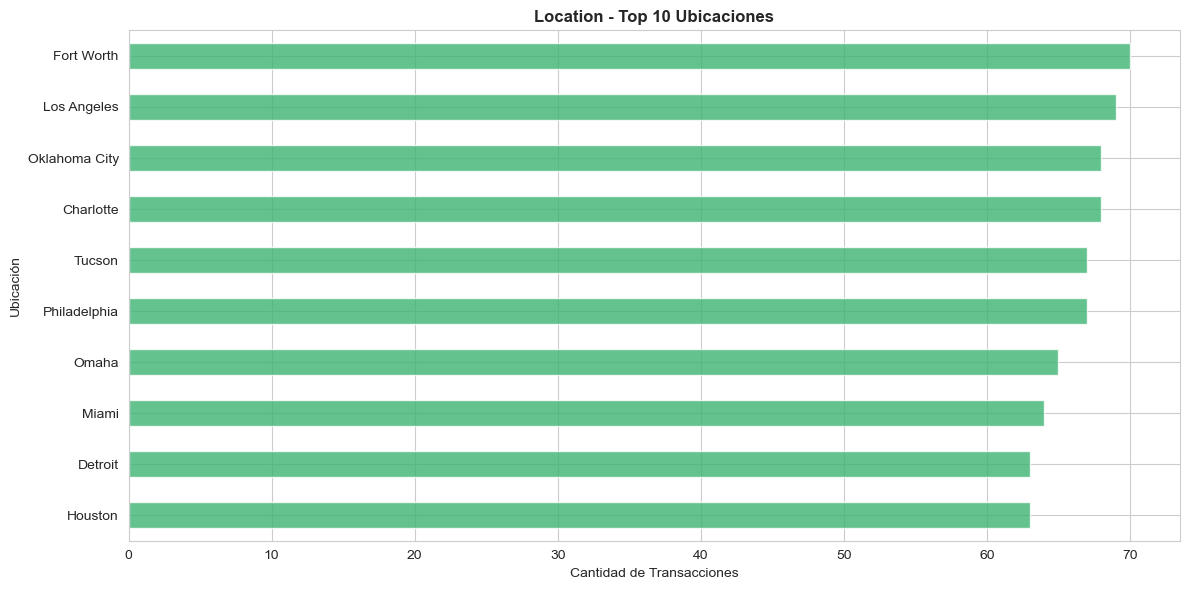

In [ ]:
# Información sobre cardinalidad
print(f"Total de ubicaciones únicas: {df['Location'].nunique()}")
print(f"Total de transacciones: {df['Location'].count()}\n")

# Top 10 ubicaciones
location_top10 = df['Location'].value_counts().head(10)
location_top10_pct = (location_top10.sum() / df['Location'].count()) * 100

print("Location - Top 10 Frecuencias:")
print(location_top10)
print(f"\nEl Top 10 representa el {location_top10_pct:.2f}% del total de transacciones\n")

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
location_top10.plot(kind='barh', ax=ax, color='mediumseagreen', alpha=0.8)
ax.set_title('Location - Top 10 Ubicaciones', fontsize=12, fontweight='bold')
ax.set_xlabel('Cantidad de Transacciones')
ax.set_ylabel('Ubicación')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## MerchantID: Top 10 (Alta Cardinalidad)

Debido a la alta cardinalidad de MerchantID, mostramos solo los 10 comerciantes más frecuentes.

Total de comerciantes únicos: 100
Total de transacciones: 2512

MerchantID - Top 10 Frecuencias:
MerchantID
M026    45
M066    34
M065    33
M013    33
M014    33
M028    33
M068    32
M001    32
M070    32
M005    32
Name: count, dtype: int64

El Top 10 representa el 13.50% del total de transacciones



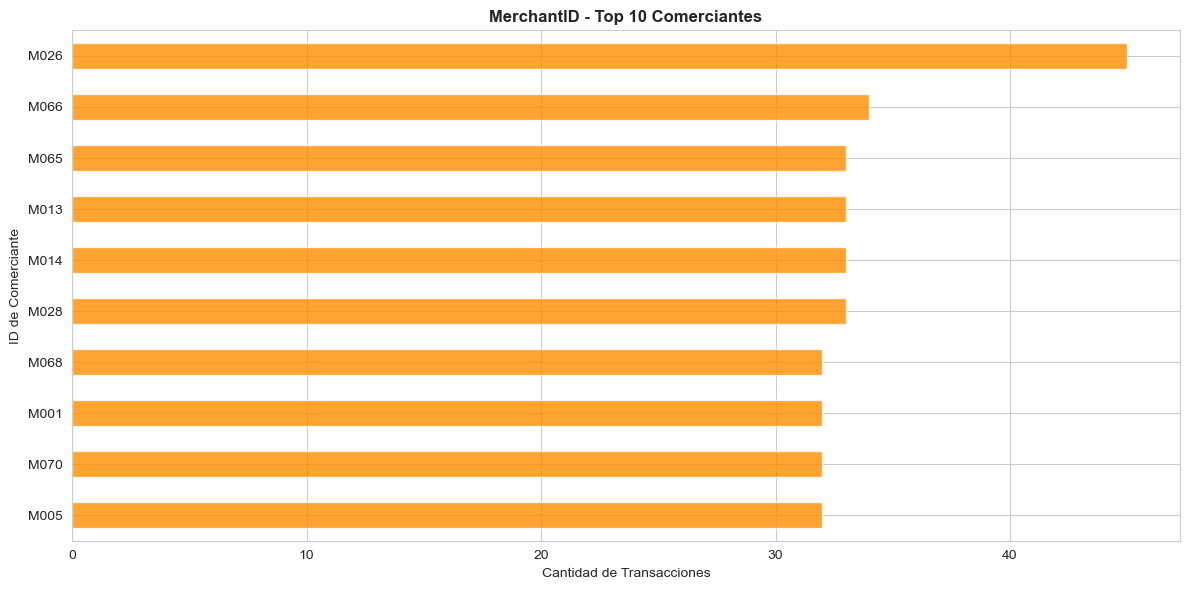

In [ ]:
# Información sobre cardinalidad
print(f"Total de comerciantes únicos: {df['MerchantID'].nunique()}")
print(f"Total de transacciones: {df['MerchantID'].count()}\n")

# Top 10 comerciantes
merchant_top10 = df['MerchantID'].value_counts().head(10)
merchant_top10_pct = (merchant_top10.sum() / df['MerchantID'].count()) * 100

print("MerchantID - Top 10 Frecuencias:")
print(merchant_top10)
print(f"\nEl Top 10 representa el {merchant_top10_pct:.2f}% del total de transacciones\n")

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
merchant_top10.plot(kind='barh', ax=ax, color='darkorange', alpha=0.8)
ax.set_title('MerchantID - Top 10 Comerciantes', fontsize=12, fontweight='bold')
ax.set_xlabel('Cantidad de Transacciones')
ax.set_ylabel('ID de Comerciante')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## IP Address: Alta Cardinalidad (Solo Estadísticas)

Debido a la muy alta cardinalidad de IP Address, solo reportamos estadísticas básicas sin visualizaciones completas.

In [ ]:
# Estadísticas de IP Address
print(f"Total de IPs únicas: {df['IP Address'].nunique():,}")
print(f"Total de transacciones: {df['IP Address'].count():,}\n")

# Top 10 IPs más frecuentes
ip_top10 = df['IP Address'].value_counts().head(10)
print("IP Address - Top 10 Frecuencias:")
print(ip_top10)

# Porcentaje del top 10
ip_top10_pct = (ip_top10.sum() / df['IP Address'].count()) * 100
print(f"\nEl Top 10 de IPs representa el {ip_top10_pct:.2f}% del total de transacciones")

Total de IPs únicas: 592
Total de transacciones: 2,512

IP Address - Top 10 Frecuencias:
IP Address
200.136.146.93    13
49.31.186.82      11
166.79.195.157    10
9.230.41.239      10
173.135.78.201    10
147.119.62.178    10
219.98.242.240     9
49.29.37.185       9
49.20.211.229      9
166.41.54.117      9
Name: count, dtype: int64

El Top 10 de IPs representa el 3.98% del total de transacciones
